# 08 — Familia F4: Markov-Switching econométrico

**Qué detecta.** Cambios de régimen en la *distribución* del retorno diario del S&P 500.
Un estado latente discreto $S_t$, gobernado por una cadena de Markov, conmuta **a la vez
la media y la varianza** del retorno. El régimen de mayor varianza (y media menor) es la
*crisis/estrés*; el de menor varianza, la *calma*. Es la tradición econométrica de
Hamilton (1989) [hamilton1989], estimada por máxima verosimilitud con el filtro de
Hamilton.

**Supuestos.** (i) Cadena de Markov de primer orden con matriz de transición constante;
(ii) retorno **gaussiano dentro de cada régimen**; (iii) número de regímenes $K$ fijado a
priori; (iv) **univariante**: solo ve el retorno del índice, no el crédito, la curva de
tipos ni la correlación entre activos.

**Detectores de la familia.**

| id | detector | módulo | papel |
|---|---|---|---|
| D05 | Markov-Switching de media y varianza | `regimenes.detectores.f4_switching.markov_switching_var` | baseline econométrico interpretable |

La familia tiene un único miembro, así que la comparación de §5 se hace entre pistas y
frente a sus parientes más cercanos: el HMM (F3, mismo aparato matemático en versión
multivariante) y la volatilidad condicional (F5, D06 GJR-GARCH-t y D11 MS-GARCH, que
añade dinámica GARCH *dentro* de cada régimen de Markov).

**Regla del notebook.** Ninguna cifra del texto está escrita a mano: todas salen de las
celdas. Por defecto el notebook no ajusta el benchmark: lee la caché verificada de
`results/benchmark/` (§3). Los ajustes sobre la muestra completa de §4.2 son
**ilustrativos y no causales** (miran toda la muestra); la evaluación honesta es siempre
la OOS walk-forward del benchmark.

**Índice**

1. [Teoría de la familia](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [D05 por pista](#s4): 4.1 estados OOS · 4.2 diagnóstico propio (probabilidad
   filtrada, parámetros, transición, filtrada vs suavizada, distribución por régimen) ·
   4.3 cobertura por crisis · 4.4 métricas y puesto en el ranking ADR-003
5. [Comparación intra-familia y con familias vecinas](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

<a id="s1"></a>
## 1. Teoría de la familia

*Fuentes: `docs/teoria/F4_markov_switching.md` (antes `memory/sota/04_markov_switching.md`),
`docs/teoria/00_estado_del_arte.md`, `docs/detectores/D05_markov_switching_var.md` y el
notebook v1 `capa1-final:capa1_exploracion/notebooks/05_markov_switching_var.ipynb` (tag git
`capa1-final`; cifras v1 en `docs/historia/capa1/resultados/`). Claves de
`docs/references.bib` entre corchetes.*

### 1.1 El modelo

Un modelo Markov-Switching (MS) describe una serie cuyos parámetros conmutan entre $K$
regímenes. En su forma más simple, la que usa D05 (`MarkovRegression` de `statsmodels`
con `trend='c'` y `switching_variance=True`):

$$
y_t = \mu_{S_t} + \sigma_{S_t}\,\varepsilon_t,\qquad \varepsilon_t \sim \mathcal N(0,1),
\qquad P(S_t=j\mid S_{t-1}=i, S_{t-2},\dots) = p_{ij},
$$

donde $y_t$ es el retorno logarítmico diario del S&P 500 (reescalado ×100 solo por
estabilidad numérica) y $P=(p_{ij})$ es una matriz fila-estocástica constante. La
dinámica es **lineal por tramos**: dentro de cada régimen el proceso es un ruido
gaussiano con su media y su varianza, pero el proceso global es no lineal y admite
cambios bruscos sin fijar a priori la fecha de la rotura [hamilton1989; ms_kimnelson1999].

Consecuencias directas de la cadena de Markov:

- **Persistencia y duración esperada.** La duración de un episodio en el régimen $k$ es
  geométrica con media $\mathbb E[D_k] = 1/(1-p_{kk})$. Una diagonal cercana a 1 produce
  regímenes pegajosos: el control del *flickering* está **parametrizado** en $P$, a
  diferencia de un clustering sin memoria (F2).
- **Distribución estacionaria** $\pi$ con $\pi^\top P = \pi^\top$: fracción de tiempo
  esperada en cada régimen.
- **Colas.** La mezcla de gaussianas con varianzas distintas es leptocúrtica, pero con la
  curtosis de los retornos diarios (la celda de §4.2 la calcula) dos gaussianas no bastan
  para reproducir los extremos; de ahí que BIC tienda a pedir un tercer régimen de
  varianza muy alta (hallazgo v1, §6).

### 1.2 Filtro de Hamilton (causal) y suavizador de Kim (anti-causal)

Sea $\eta_t$ el vector de densidades $f(y_t\mid S_t=k)$ y
$\xi_{t\mid s}=P(S_t=\cdot\mid y_{1:s})$. El **filtro de Hamilton** alterna predicción y
actualización:

$$
\xi_{t\mid t-1} = P^\top \xi_{t-1\mid t-1},\qquad
\xi_{t\mid t} = \frac{\xi_{t\mid t-1}\odot \eta_t}{\mathbf 1^\top(\xi_{t\mid t-1}\odot\eta_t)},\qquad
\log L = \sum_t \log \mathbf 1^\top(\xi_{t\mid t-1}\odot\eta_t).
$$

Las probabilidades **filtradas** $\xi_{t\mid t}$ solo usan el pasado: son **causales**, las
únicas válidas para una señal en tiempo real. El **suavizador de Kim** [ms_kim1994]
recorre la muestra hacia atrás,

$$
\xi_{t\mid T} = \xi_{t\mid t}\odot\Big[P\,\big(\xi_{t+1\mid T}\oslash \xi_{t+1\mid t}\big)\Big],
$$

y produce $P(S_t\mid y_{1:T})$, que usa **el futuro**. Las suavizadas dan dataciones
históricas muy nítidas (son las que aparecen en la mayoría de papers), pero usarlas como
señal es *look-ahead*. §4.2 las compara en limpio sobre un ajuste de muestra completa.

### 1.3 Identificación, número de regímenes y etiquetado

- **$K$ no se estima dentro del modelo.** Se elige por AIC/BIC o por teoría; el test de
  razón de verosimilitud de $K$ frente a $K+1$ no es estándar (parámetros de transición no
  identificados bajo la nula) [ms_guidolin2011]. D05 fija el $K$ del registro (§2) como
  baseline interpretable calma/crisis; §4.2 permite reportar $K+1$ como referencia.
- **Verosimilitud multimodal.** El EM/ML tiene óptimos locales; `search_reps` controla
  arranques aleatorios (en el benchmark se deja el valor del registro por coste).
- **Label switching.** Los índices de los regímenes son intercambiables; el núcleo
  (`RegimeDetector.label_states_economically`) los reordena por criterio económico
  **vol-primario** (0 = calma … $K-1$ = crisis, con el retorno solo como desempate) usando
  el retorno del S&P 500 del *train* de cada fold.

### 1.4 Del modelo al detector D05 (causalidad en el walk-forward)

`MarkovRegression` es un estimador *batch*: no puede reestimarse dentro de cada bloque de
test. D05 extrae $\mu_k,\sigma^2_k,P$ del ajuste del *train* y, para predecir el bloque,
corre un **filtro forward gaussiano propio** con esos parámetros congelados sobre
`[burn-in del train] + bloque`, devolviendo solo el bloque: cero *look-ahead*
intra-bloque (en v1 se verificó frente a `statsmodels` con diferencia a precisión de
máquina). El estado duro es el argmax del filtrado; `p_crisis` es la probabilidad
filtrada del régimen de crisis. El reajuste se hace cada `step` sesiones (§2): el EM es
caro con ventana *expanding*, y los regímenes de varianza son lo bastante persistentes
para reajustes espaciados.

### 1.5 Relación con otras familias

- **HMM (F3)**: el MS gaussiano y el HMM gaussiano son **dos puntos del mismo continuo**
  (estado latente markoviano + emisiones paramétricas; filtro de Hamilton ≡ algoritmo
  forward; ML ≡ Baum-Welch). La diferencia práctica es de tradición: MS univariante,
  interpretable y con inferencia formal; HMM multivariante con emisiones flexibles
  [hmm_angtimmermann2012; ms_angtimmermann2012].
- **Volatilidad (F5)**: el MS "puro" asume varianza **constante dentro** de cada régimen;
  el RS/MS-GARCH (D11) deja que evolucione tipo GARCH dentro de cada régimen
  [vol_haasmittnikpaolella2004]. D06 hace lo contrario: dinámica GARCH con un único
  régimen y un umbral.
- **Aplicaciones a mercados**: regímenes en correlaciones y asignación internacional
  [angbekaert2002], cuatro regímenes conjuntos acciones-bonos [guidolintimmermann2007],
  MS lognormal de dos regímenes sobre el S&P 500 [ms_hardy2001].

### Referencias

`hamilton1989` · `ms_kim1994` · `ms_kimnelson1999` · `ms_guidolin2011` ·
`ms_angtimmermann2012` · `ms_hardy2001` · `ms_statsmodels` · `angbekaert2002` ·
`guidolintimmermann2007` · `hmm_angtimmermann2012` · `vol_haasmittnikpaolella2004`
(todas en `docs/references.bib`).

<a id="s2"></a>
## 2. Configuración (desde el registro)

La tabla se genera desde el registro, que es la única fuente de verdad de la
configuración del benchmark: features de entrada, parámetros pasados al constructor,
semilla, frecuencia de reajuste (`step`), tamaño del entrenamiento inicial y tipo de
ventana por pista. La fila `params_por_defecto` muestra los parámetros que el
registro **no** fija y que, por tanto, toman el valor por defecto de la clase (p. ej.
los umbrales de histéresis de D06). Las configuraciones son hipótesis previas al
benchmark: no se ajustaron mirando sus métricas.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS
from regimenes.features import TRADING_DAYS

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f4_markov_switching'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F4 — Markov-Switching econométrico'
DETECTORES = ['D05']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F4 — Markov-Switching econométrico: D05 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f4_markov_switching


In [2]:
CONFIG = inf.tabla_configuracion(SPECS)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                      D05                                         
pista                                                     A                                        B
detector                          Markov-Switching varianza                Markov-Switching varianza
familia_registro                           Markov-Switching                         Markov-Switching
clase               markov_switching_var.MarkovSwitchingVar  markov_switching_var.MarkovSwitchingVar
n_features                                                1                                        1
features                                          SP500_ret                                SP500_ret
params_declarados             feature=SP500_ret, n_states=2            feature=SP500_ret, n_states=2
params_por_defecto               scale=100.0, search_reps=0               scale=100.0, search_reps=0
params_efectivos                                 n_states=2                               n_states=2
semilla                                     no consume azar                          no consume azar
step                                                     63                                       63
train_inicial                           2016 ses. (~8 años)                       756 ses. (~3 años)
ventana                                           expanding                                expanding
lento                                                  True                                     True
variante_v2                                               —                                        —

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [3]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

,pista,id,estado,detalle
0,A,D05,cache,caché verificada: results\benchmark\metrics\A_...
1,B,D05,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 2 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


### 3.1 Datos de apoyo y utilidades de figura

Para las figuras hacen falta el precio del S&P 500 (espina cruda de `data/raw`) y, para
los diagnósticos ilustrativos, la misma matriz `X` que ve el benchmark (panel de la
pista recortado al índice común de los doce detectores, `X_PISTA`). Las utilidades de
figura y tabla son las comunes a los notebooks 05–11 (`regimenes.informes`): estados OOS
sobre el S&P 500, cobertura por crisis y resumen del ranking ADR-003.

In [4]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))
X_PISTA = {(t, d): CTX.matriz(t, s.features) for (t, d), s in SPECS.items()}   # X del benchmark

# Utilidades comunes 05–11 (implementación en regimenes.informes; aquí solo se fijan los datos).
def estado_crisis(t, d):
    """Estado canónico de crisis del detector (n_states - 1)."""
    return RES.estado_crisis(t, d)


def es_crisis(t, d):
    """Serie booleana OOS: sesión en el estado de crisis."""
    return RES.es_crisis(t, d)


def tabla_cobertura(t, d):
    """Cobertura OOS por crisis (IC bootstrap por bloques), detección por evento y lead/lag."""
    return inf.tabla_cobertura(METRICAS.loc[(t, d)], CRISIS[t])


def tabla_trampas(t, d):
    """Activación en las ventanas trampa (fracción de sesiones marcadas; menor es mejor)."""
    return inf.tabla_trampas(METRICAS.loc[(t, d)], TRAMPAS)


def figura_estados(t, d, diagnostico=None, titulo_diag=None, **kw):
    """Arriba estados OOS sobre el S&P 500 con franjas de crisis/trampas; abajo el diagnóstico
    propio (``diagnostico(ax)``) o, por defecto, P(crisis) OOS del panel."""
    fig, axes = inf.figura_estados_oos(
        SP500, PANELES[(t, d)], RES.n_estados(t, d), crisis=CRISIS[t], trampas=TRAMPAS,
        titulo=f'{d} {SPECS[(t, d)].label} — pista {t}: estados OOS (causal) sobre el S&P 500',
        diagnostico=diagnostico, titulo_diagnostico=titulo_diag, **kw)
    guardar(fig, f'{d}_{t}_estados_oos')
    plt.show()
    return axes


def figura_cobertura(t, d, **kw):
    """Cobertura por crisis (rojo = detectada) y activación en trampas (gris) de una pista."""
    tab = tabla_cobertura(t, d)
    fig, _ = inf.figura_cobertura(
        tab, tabla_trampas(t, d), min_run=MIN_RUN,
        titulo=f'{d} — pista {t}: cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; barras = IC bootstrap; gris = trampas)', **kw)
    guardar(fig, f'{d}_{t}_cobertura_crisis')
    plt.show()
    return tab


def resumen_ranking(ids):
    """Métricas y puesto en el ranking de detección ADR-003 (columna 'de' = detectores en la pista)."""
    return RES.resumen_ranking(ids)


def franjas_crisis(ax, t, alpha=0.10):
    """Sombrea las ventanas [pico, suelo] de la pista (labels congeladas del spec)."""
    inf.franjas_eventos(ax, CRISIS[t], None, alpha_crisis=alpha)


COLS_METRICAS = ['n_oos', 'oos_start', 'oos_end', 'det_event_recall', 'det_n_detectados', 'det_n_eventos',
                 'det_precision', 'det_base_rate', 'det_lift_precision', 'det_marked_rate',
                 'det_mean_crisis_run', 'mean_crisis_coverage', 'false_alarm_rate', 'switching_rate',
                 'mean_regime_duration', 'label_stability', 'log_likelihood', 'aic', 'bic',
                 'elapsed_seconds']
COLS_RANKING = ['puesto_deteccion', 'nivel_etiqueta', 'score_deteccion', 'puesto_legacy']


def resumen_metricas(d):
    """Métricas verificadas + puesto ADR-003 de un detector (una columna por pista)."""
    filas = {}
    for t in PISTAS:
        serie = {c: METRICAS.loc[(t, d)].get(c, np.nan) for c in COLS_METRICAS}
        if 'mean_crisis_coverage' in RANK.columns:
            serie['mean_crisis_coverage'] = RANK.loc[(t, d), 'mean_crisis_coverage']
        serie.update({c: RANK.loc[(t, d)].get(c, np.nan) for c in COLS_RANKING})
        serie['n_detectores_en_pista'] = N_PISTA[t]
        filas[f'pista {t}'] = serie
    return pd.DataFrame(filas)

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


<a id="s4"></a>
## 4. Detector a detector — D05 Markov-Switching de media y varianza

<a id="s4-1"></a>
### 4.1 Estados OOS sobre el S&P 500

Arriba, el S&P 500 (escala log) con los días que el walk-forward causal marcó como
**crisis** (sombreado rojo), las ventanas `[pico, suelo]` de crisis de la pista (franjas
azules) y las trampas no-crisis (gris). Abajo, la probabilidad **filtrada** de crisis
OOS $P(S_t=\text{crisis}\mid y_{\le t})$ con el umbral 0,5.

#### Pista A

figura -> results/detectores/f4_markov_switching/D05_A_estados_oos.png


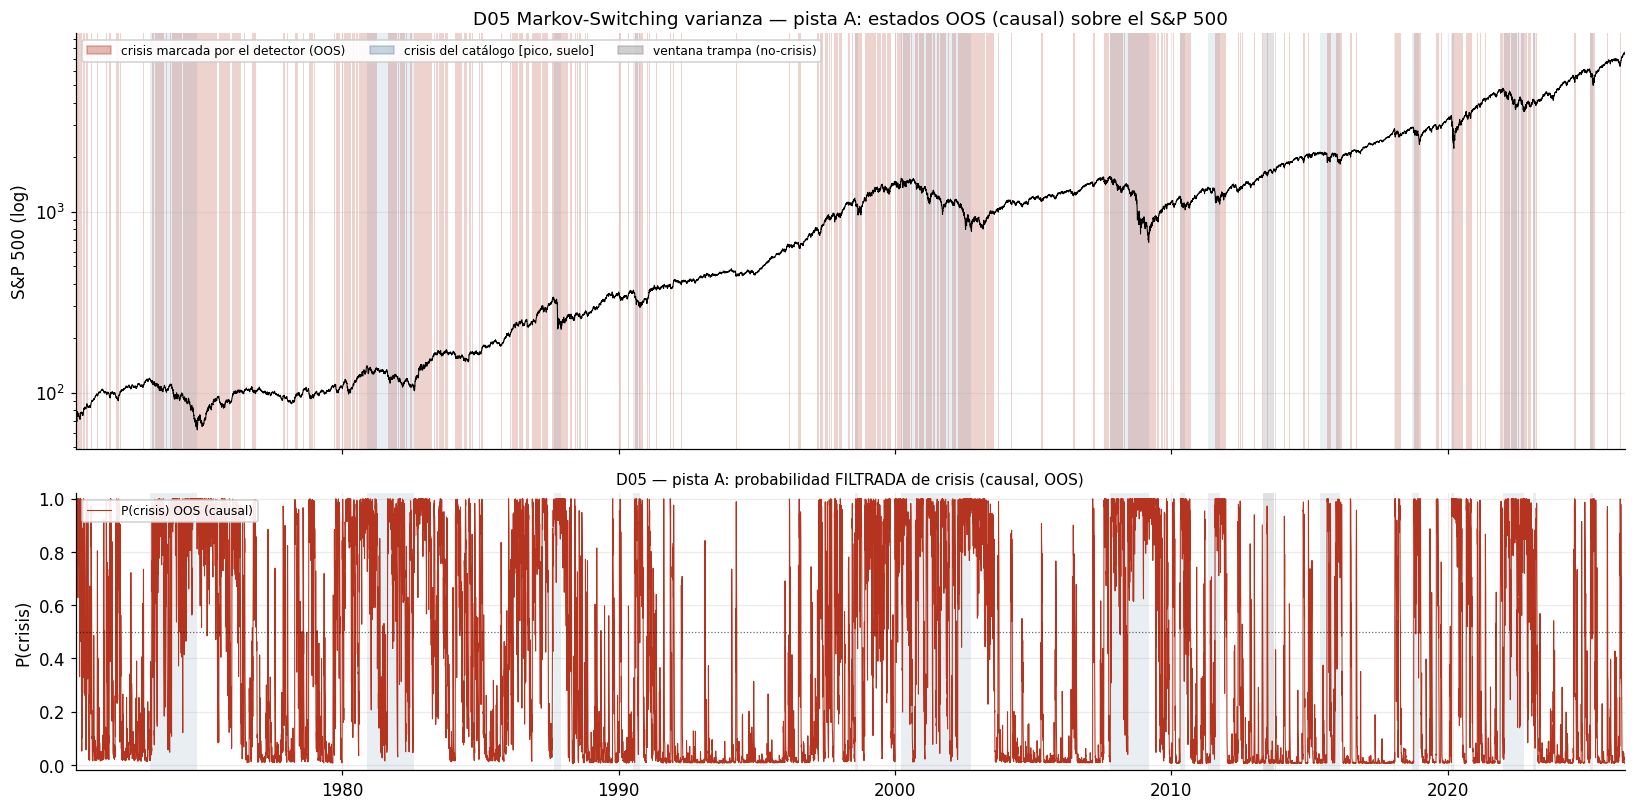

D05/A: 38.2% de las sesiones OOS marcadas como crisis; 965 cambios de estado.


#### Pista B

figura -> results/detectores/f4_markov_switching/D05_B_estados_oos.png


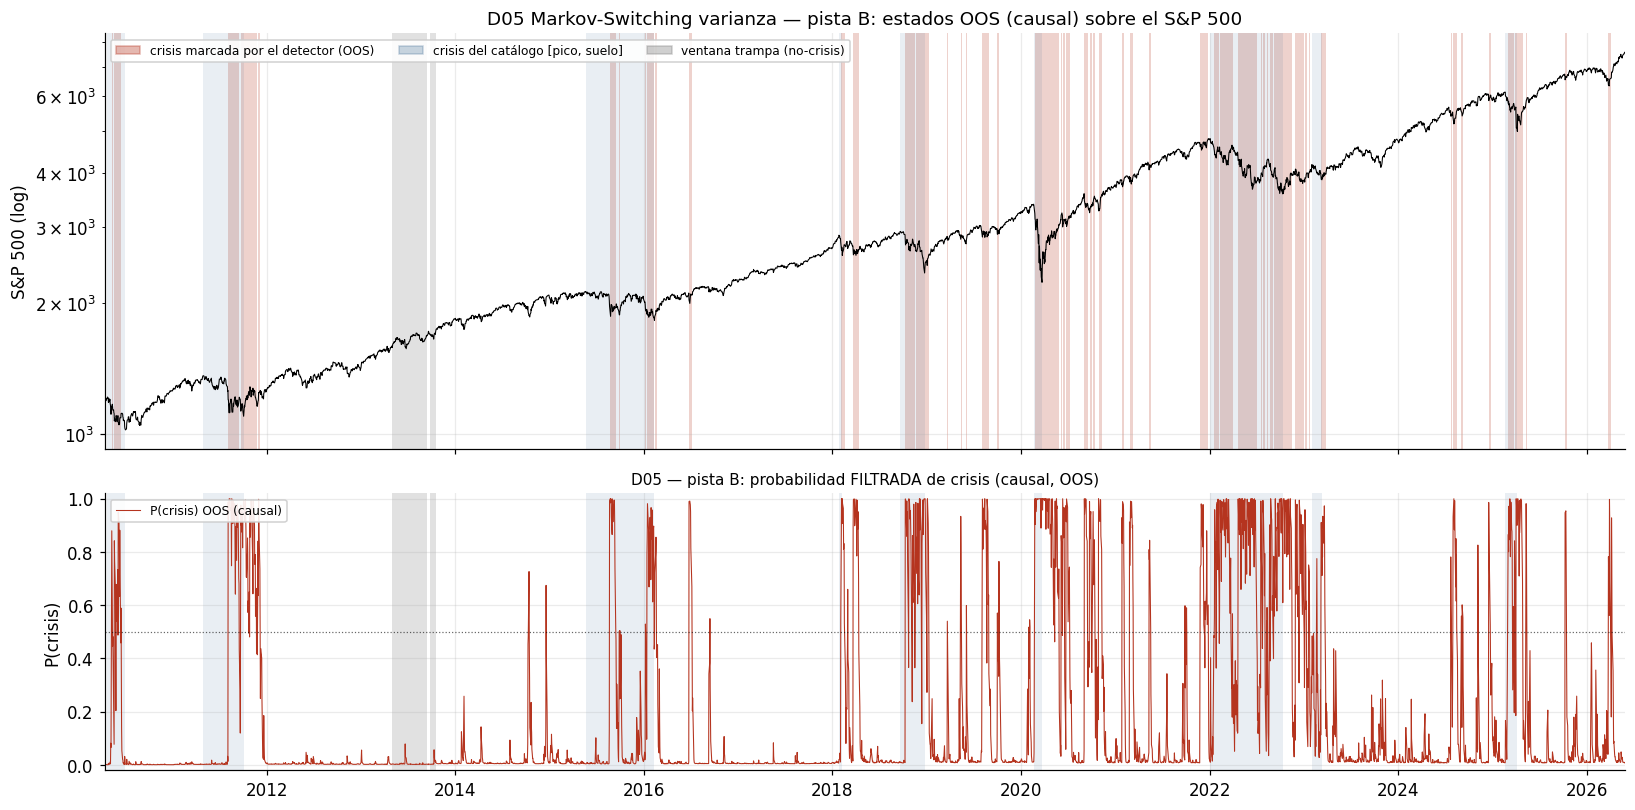

D05/B: 17.3% de las sesiones OOS marcadas como crisis; 176 cambios de estado.


In [5]:
for t in PISTAS:
    display(Markdown(f'#### Pista {t}'))
    figura_estados(t, 'D05', titulo_diag=f'D05 — pista {t}: probabilidad FILTRADA de crisis (causal, OOS)')
    print(f"D05/{t}: {float(es_crisis(t, 'D05').mean()):.1%} de las sesiones OOS marcadas como crisis; "
          f"{int((PANELES[(t, 'D05')]['state'].diff().fillna(0) != 0).sum())} cambios de estado.")

<a id="s4-2"></a>
### 4.2 Diagnóstico propio

**(a) Parámetros por régimen — ajuste ilustrativo sobre la muestra completa (NO causal).**
Una única estimación sobre toda la matriz `X` de cada pista (la misma que ve el
benchmark) permite leer lo que hace interpretable a D05: media y volatilidad por régimen
(en % diario y anualizadas), persistencia $p_{kk}$ y duración esperada $1/(1-p_{kk})$.
La verificación clave es que el régimen canónico de crisis sea el de **mayor varianza**
(orientación no invertida). Estas cifras no entran en ninguna métrica: la evaluación es
la OOS de §4.1/§4.3.

In [6]:
DIAGNOSTICO_ILUSTRATIVO = True  # un ajuste por pista sobre la muestra completa (segundos–minutos)

AJUSTES_D05 = {}
if DIAGNOSTICO_ILUSTRATIVO:
    for t in PISTAS:
        X = X_PISTA[(t, 'D05')]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            det = SPECS[(t, 'D05')].factory().fit(X)
            det.label_states_economically(X, market_returns=X['SP500_ret'])
        AJUSTES_D05[t] = det
        mu, var = det.means_canonical(), det.variances_canonical()
        A = det.transition_canonical()
        etiquetas = ['calma'] + [f'intermedio {k}' for k in range(1, det.n_states - 1)] + ['crisis']
        tabla = pd.DataFrame({
            'régimen': etiquetas,
            'μ (% diario)': mu,
            'μ (% anualizado)': mu * TRADING_DAYS,
            'σ (% diario)': np.sqrt(var),
            'σ (% anualizada)': np.sqrt(var * TRADING_DAYS),
            'p_kk (persistencia)': np.diag(A),
            'duración esperada (sesiones)': 1.0 / (1.0 - np.diag(A)),
        }).set_index('régimen')
        display(Markdown(f'#### Pista {t} — muestra {X.index.min().date()} → {X.index.max().date()} '
                         f'({len(X)} sesiones)'))
        display(tabla.round(4))
        r = X['SP500_ret']
        print(f'crisis canónica = régimen de MAYOR varianza: '
              f'{bool(np.isclose(var[det.crisis_state], var.max()))}')
        print(f'curtosis (exceso) del retorno diario en la muestra: {r.kurt():.1f}  '
              f'| logL = {det.score(X):.1f} | AIC = {det.aic(X):.1f} | BIC = {det.bic(X):.1f}')

#### Pista A — muestra 1962-03-29 → 2026-05-29 (16149 sesiones)

,μ (% diario),μ (% anualizado),σ (% diario),σ (% anualizada),p_kk (persistencia),duración esperada (sesiones)
régimen,,,,,,
calma,0.0632,15.9225,0.6642,10.5446,0.9892,92.7247
crisis,-0.0789,-19.8771,1.7619,27.9694,0.9659,29.2854


crisis canónica = régimen de MAYOR varianza: True


curtosis (exceso) del retorno diario en la muestra: 24.7  | logL = -20726.2 | AIC = 41464.4 | BIC = 41510.5


#### Pista B — muestra 2007-04-11 → 2026-05-29 (4815 sesiones)

,μ (% diario),μ (% anualizado),σ (% diario),σ (% anualizada),p_kk (persistencia),duración esperada (sesiones)
régimen,,,,,,
calma,0.0997,25.1369,0.6956,11.0423,0.9843,63.6250
crisis,-0.1414,-35.6381,2.1066,33.4408,0.9574,23.4604


crisis canónica = régimen de MAYOR varianza: True


curtosis (exceso) del retorno diario en la muestra: 12.4  | logL = -6786.0 | AIC = 13584.0 | BIC = 13622.9


**(b) Matriz de transición.** Diagonal alta ⇒ regímenes persistentes (poco *flickering*);
la asimetría calma/crisis (la calma dura más) es la firma habitual de los mercados:
expansiones largas, estrés breve e intenso.

figura -> results/detectores/f4_markov_switching/D05_transicion.png


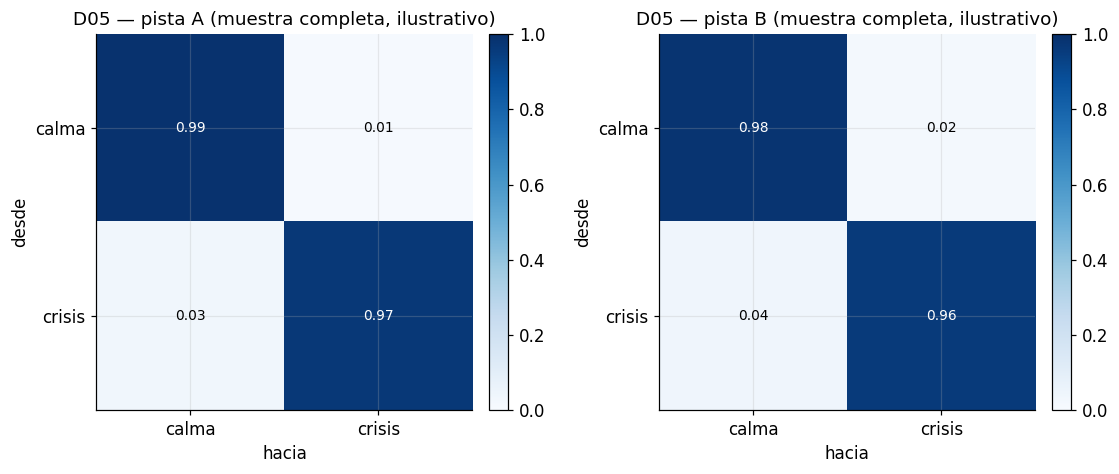

In [7]:
if AJUSTES_D05:
    fig, axes = plt.subplots(1, len(AJUSTES_D05), figsize=(5.2 * len(AJUSTES_D05), 4.4))
    axes = np.atleast_1d(axes)
    for ax, (t, det) in zip(axes, AJUSTES_D05.items()):
        etiquetas = ['calma'] + [f'int. {k}' for k in range(1, det.n_states - 1)] + ['crisis']
        viz.plot_transition_matrix(det.transition_canonical(), labels=etiquetas, ax=ax,
                                   title=f'D05 — pista {t} (muestra completa, ilustrativo)')
    fig.tight_layout()
    guardar(fig, 'D05_transicion')
    plt.show()

**(c) Filtrada vs suavizada (el sesgo de *look-ahead*, en limpio).** Sobre el mismo ajuste
de muestra completa, la probabilidad de crisis **filtrada** $P(S_t\mid y_{1:t})$ (causal)
frente a la **suavizada** $P(S_t\mid y_{1:T})$ (usa el futuro). El panel inferior es la
diferencia suavizada − filtrada: donde es positiva (típicamente justo antes de una
crisis), el suavizado "ya sabe" lo que viene. El área de esa banda mide cuánto regalo de
información supondría reportar suavizadas; por eso el benchmark usa siempre filtradas.

figura -> results/detectores/f4_markov_switching/D05_A_filtrada_vs_suavizada.png


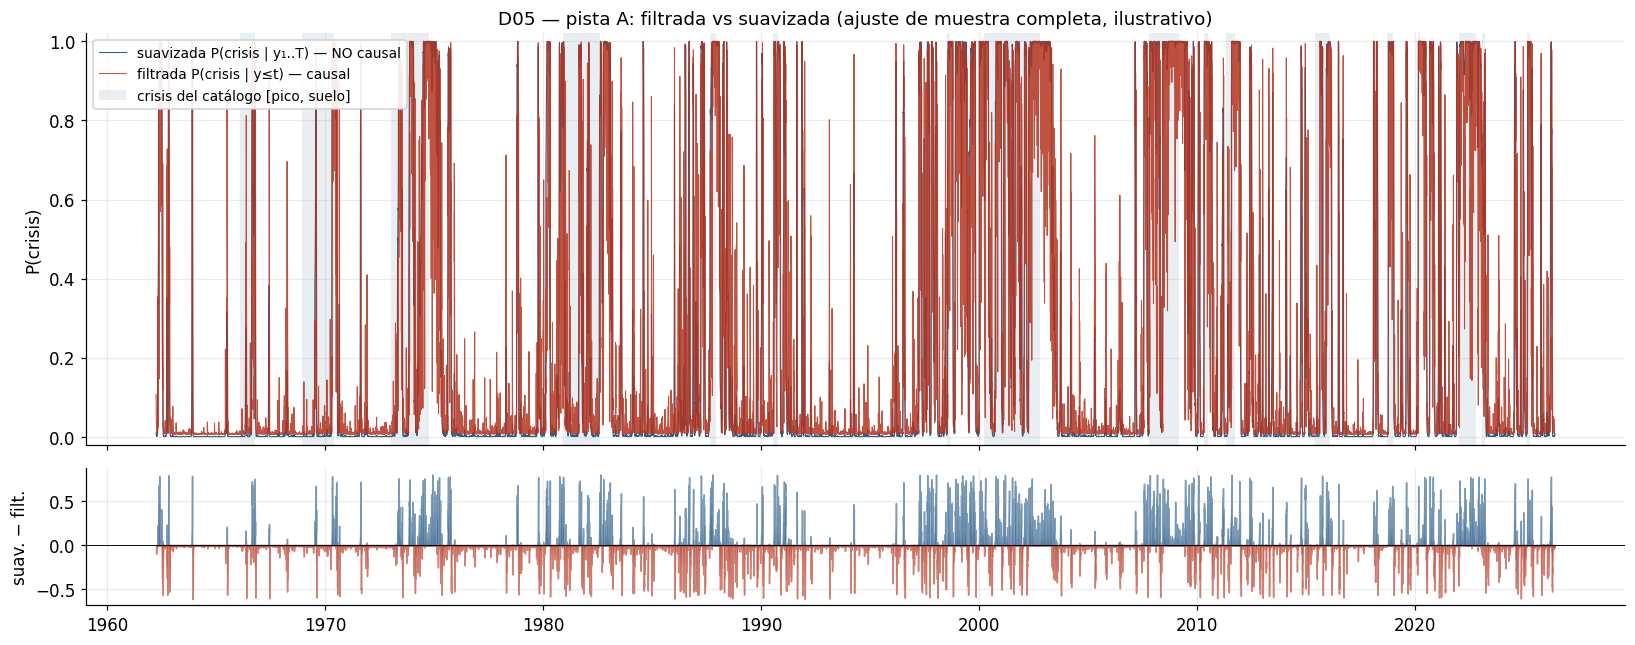

Pista A: corr(filtrada, suavizada) = 0.892; media |suavizada − filtrada| = 0.089; días con desacuerdo en el argmax = 7.7%


figura -> results/detectores/f4_markov_switching/D05_B_filtrada_vs_suavizada.png


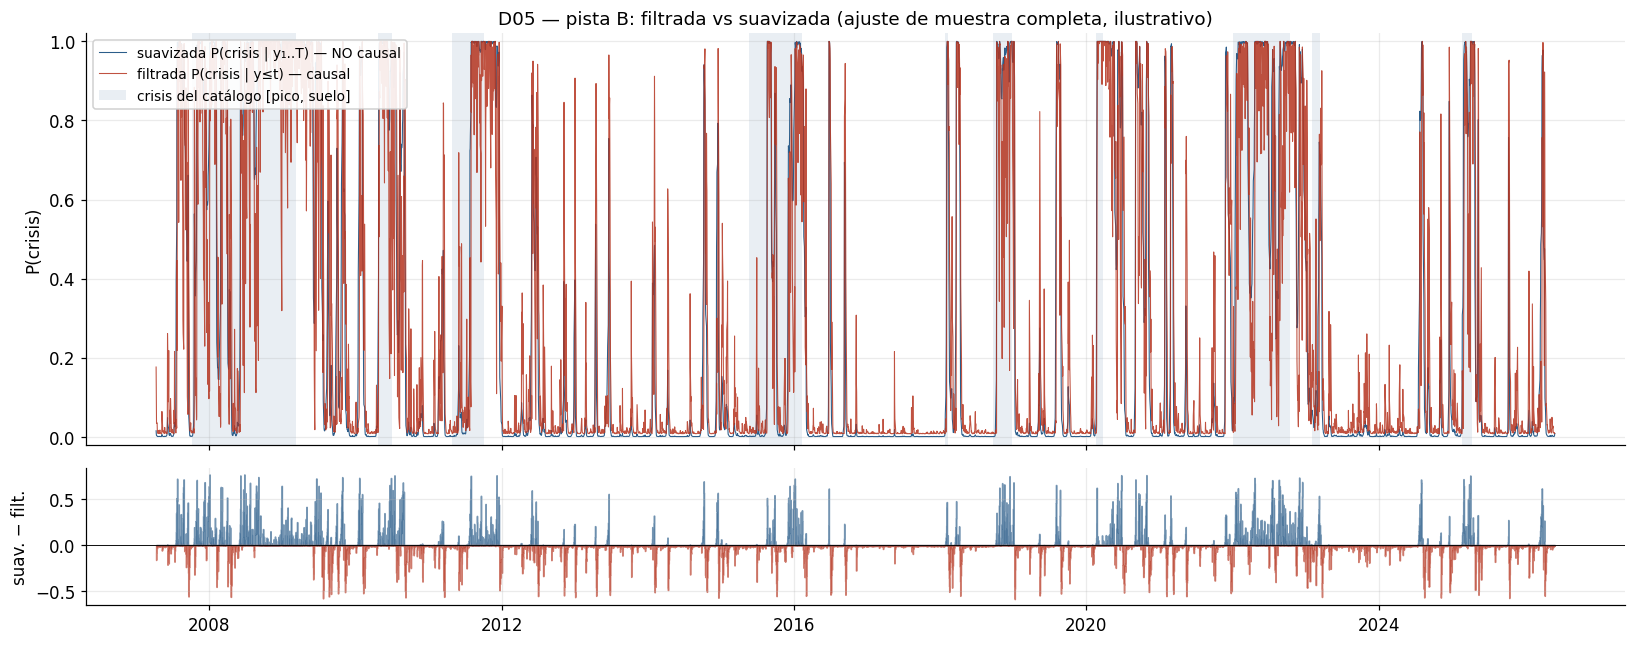

Pista B: corr(filtrada, suavizada) = 0.900; media |suavizada − filtrada| = 0.092; días con desacuerdo en el argmax = 7.6%


In [8]:
for t, det in AJUSTES_D05.items():
    configure_evaluation(t)
    idx = det._endog(X_PISTA[(t, 'D05')]).dropna().index
    cs = det.crisis_state
    p_f = pd.Series(det.insample_proba('filtered')[:, cs], index=idx)
    p_s = pd.Series(det.insample_proba('smoothed')[:, cs], index=idx)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(idx, p_s, color=viz.C_LONG, lw=0.7, label='suavizada P(crisis | y₁..T) — NO causal')
    ax1.plot(idx, p_f, color=viz.C_CRISIS, lw=0.7, alpha=0.85, label='filtrada P(crisis | y≤t) — causal')
    franjas_crisis(ax1, t)
    ax1.set_ylim(-0.02, 1.02); ax1.set_ylabel('P(crisis)')
    ax1.set_title(f'D05 — pista {t}: filtrada vs suavizada (ajuste de muestra completa, ilustrativo)')
    ax1.legend(loc='upper left', framealpha=0.9)
    dif = p_s - p_f
    ax2.fill_between(idx, 0, dif.clip(lower=0), color=viz.C_LONG, alpha=0.6, step='mid')
    ax2.fill_between(idx, 0, dif.clip(upper=0), color=viz.C_CRISIS, alpha=0.6, step='mid')
    ax2.axhline(0, color='black', lw=0.6); ax2.set_ylabel('suav. − filt.')
    fig.tight_layout()
    guardar(fig, f'D05_{t}_filtrada_vs_suavizada')
    plt.show()
    print(f'Pista {t}: corr(filtrada, suavizada) = {p_f.corr(p_s):.3f}; '
          f'media |suavizada − filtrada| = {dif.abs().mean():.3f}; '
          f'días con desacuerdo en el argmax = {float(((p_f > 0.5) != (p_s > 0.5)).mean()):.1%}')

**(d) Distribución del retorno OOS por régimen (el mecanismo de Hamilton, fuera de
muestra).** Se separa el retorno diario OOS según el régimen que el filtro causal asignó.
Si el mecanismo funciona, el régimen de crisis debe tener dispersión mucho mayor y media menor
que la calma; ahora sobre datos que el modelo no vio. La media no tiene por qué ser negativa: el
régimen de alta varianza recoge también los rebotes de los mercados bajistas. La celda imprime la
comparación por pista.

figura -> results/detectores/f4_markov_switching/D05_retorno_oos_por_regimen.png


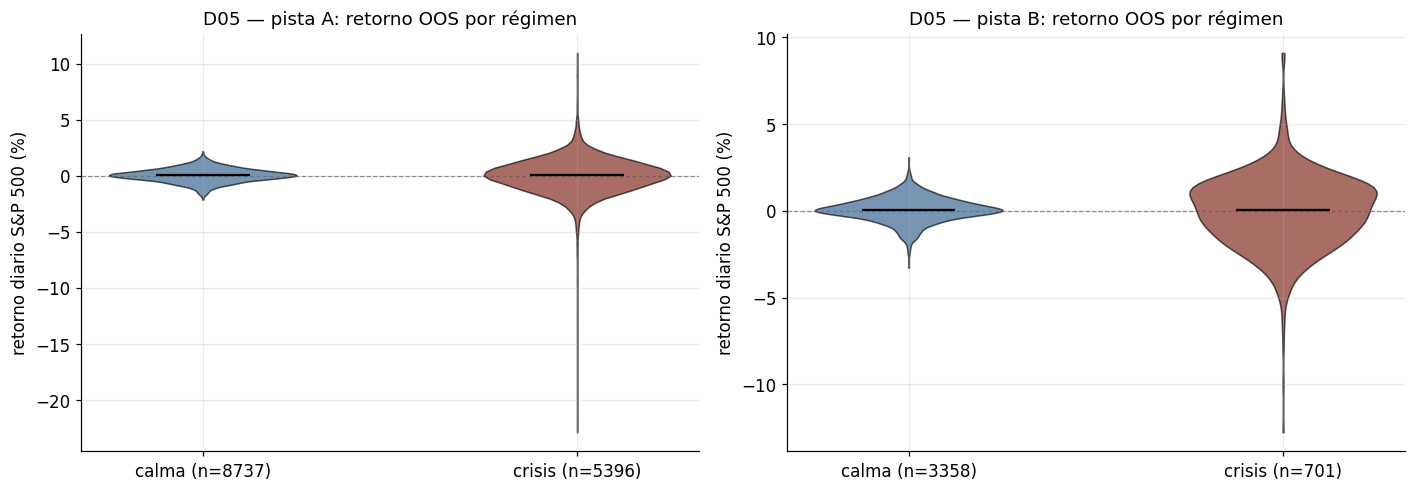

sesiones  media (%)  desv. típica (%)  retorno anualizado (%)  vol anualizada (%)
pista régimen                                                                                    
A     estado 0      8737      0.052             0.615                  12.993               9.771
      crisis        5396      0.001             1.573                   0.300              24.974
B     estado 0      3358      0.066             0.717                  16.579              11.385
      crisis         701     -0.052             2.106                 -12.988              33.434

Pista A: vol anualizada crisis/calma = 2.56×; retorno anualizado crisis +0.3 % vs calma +13.0 % → media menor que la calma, pero no negativa.
Pista B: vol anualizada crisis/calma = 2.94×; retorno anualizado crisis -13.0 % vs calma +16.6 % → media menor que la calma y negativa.


In [9]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(6.5 * len(PISTAS), 4.6))
filas = []
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    panel = PANELES[(t, 'D05')]
    cs = estado_crisis(t, 'D05')
    ret = (X_PISTA[(t, 'D05')]['SP500_ret'].reindex(panel.index) * 100.0)
    viz.plot_distribution_by_regime(ret, panel['state'], crisis_state=cs,
                                    labels={0: 'calma', cs: 'crisis'}, kind='violin', ax=ax,
                                    xlabel='retorno diario S&P 500 (%)',
                                    title=f'D05 — pista {t}: retorno OOS por régimen')
    ax.axhline(0, color='grey', ls='--', lw=0.8, zorder=0)
    for s, g in ret.groupby(panel['state']):
        filas.append({'pista': t, 'régimen': 'crisis' if s == cs else f'estado {s}',
                      'sesiones': len(g), 'media (%)': g.mean(), 'desv. típica (%)': g.std(),
                      'retorno anualizado (%)': g.mean() * TRADING_DAYS,
                      'vol anualizada (%)': g.std() * np.sqrt(TRADING_DAYS)})
fig.tight_layout()
guardar(fig, 'D05_retorno_oos_por_regimen')
plt.show()
RET_POR_REGIMEN_D05 = pd.DataFrame(filas).set_index(['pista', 'régimen'])
display(RET_POR_REGIMEN_D05.round(3))
for t in PISTAS:
    g = RET_POR_REGIMEN_D05.loc[t]
    cri, cal = g.loc['crisis'], g.drop(index='crisis').iloc[0]
    print(f"Pista {t}: vol anualizada crisis/calma = {cri['vol anualizada (%)'] / cal['vol anualizada (%)']:.2f}×; "
          f"retorno anualizado crisis {cri['retorno anualizado (%)']:+.1f} % vs calma {cal['retorno anualizado (%)']:+.1f} % → "
          + ('media menor que la calma' if cri['media (%)'] < cal['media (%)'] else 'media NO menor que la calma')
          + (' y negativa.' if cri['media (%)'] < 0 else ', pero no negativa.'))

**(e) Opcional: $K$ frente a $K+1$ por AIC/BIC.** Reproduce la selección de número de
regímenes de v1 sobre los datos v2 (ajuste de muestra completa, ilustrativo). Está
desactivada por defecto (`EXPLORAR_K = False`) porque un tercer régimen multiplica el coste del EM.

In [10]:
EXPLORAR_K = False  # True: ajusta también K+1 regímenes por pista (más lento)

if EXPLORAR_K:
    from regimenes.detectores.f4_switching.markov_switching_var import MarkovSwitchingVar
    filas = []
    for t in PISTAS:
        X = X_PISTA[(t, 'D05')]
        k0 = SPECS[(t, 'D05')].params['n_states']
        for k in (k0, k0 + 1):
            params = {**SPECS[(t, 'D05')].params, 'n_states': k}
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                det_k = MarkovSwitchingVar(**params).fit(X)
            filas.append({'pista': t, 'K': k, 'logL': det_k.score(X), 'n_parámetros': det_k.n_parameters(),
                          'AIC': det_k.aic(X), 'BIC': det_k.bic(X),
                          'σ por régimen (% diario)': np.round(np.sqrt(det_k.variances_canonical()), 3)})
    SELECCION_K = pd.DataFrame(filas).set_index(['pista', 'K'])
    display(SELECCION_K)
    for t, g in SELECCION_K.groupby(level='pista'):
        print(f"Pista {t}: K* por AIC = {g['AIC'].idxmin()[1]}, K* por BIC = {g['BIC'].idxmin()[1]}")
else:
    print('EXPLORAR_K = False: selección de K no ejecutada (ver hallazgo v1 en §6).')

EXPLORAR_K = False: selección de K no ejecutada (ver hallazgo v1 en §6).


<a id="s4-3"></a>
### 4.3 Cobertura por crisis

Para cada crisis de la pista con días OOS: cobertura (fracción de sesiones de
`[pico, suelo]` marcadas como crisis) con su IC bootstrap por bloques, detección por
evento (racha mínima de ADR-003) y *lead/lag* frente al suelo del *drawdown* (negativo =
la señal llega antes del suelo). Ojo: `metricas.lead_lag` toma el primer cruce sostenido en una ventana fija antes del suelo; un valor en el tope de esa ventana (saturado) o anterior al pico de la crisis es una alarma ya encendida, no anticipación (ver 10 §4.3 e `inf.clasificar_lead_lag`). Debajo, la activación en las trampas no-crisis (bajo es
bueno). Las crisis que caen en el entrenamiento inicial no aparecen (NaN).

#### Pista A

figura -> results/detectores/f4_markov_switching/D05_A_cobertura_crisis.png


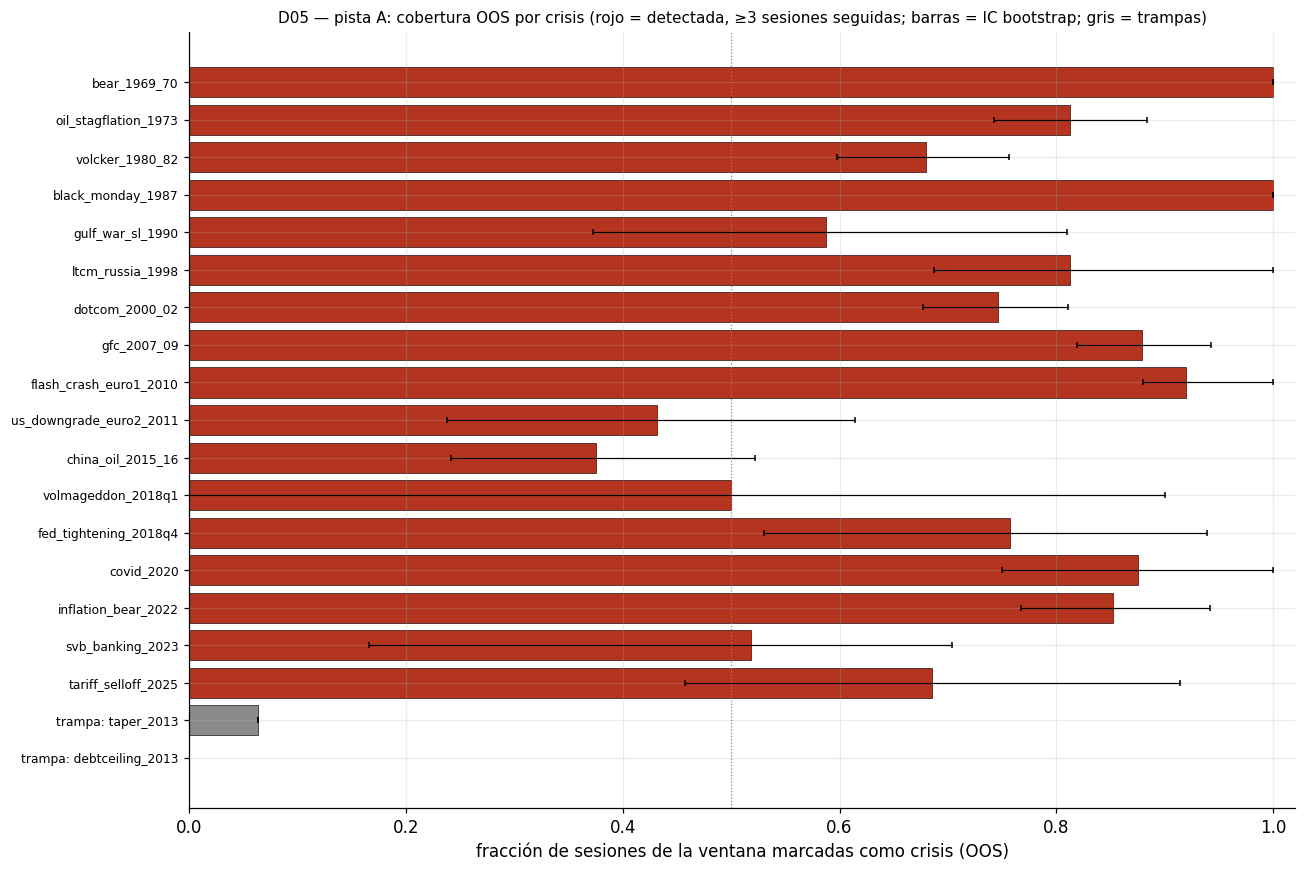

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,1.000,1.000,1.000,1.0,-10.0
oil_stagflation_1973,1973-01-11,1974-10-03,0.812,0.743,0.883,1.0,-247.0
volcker_1980_82,1980-11-28,1982-08-12,0.680,0.597,0.756,1.0,-245.0
black_monday_1987,1987-08-25,1987-12-04,1.000,1.000,1.000,1.0,-252.0
gulf_war_sl_1990,1990-07-16,1990-10-11,0.587,0.373,0.810,1.0,-251.0
ltcm_russia_1998,1998-07-17,1998-08-31,0.812,0.688,1.000,1.0,-251.0
dotcom_2000_02,2000-03-24,2002-10-09,0.746,0.677,0.811,1.0,-252.0
gfc_2007_09,2007-10-09,2009-03-09,0.879,0.819,0.942,1.0,-252.0
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.920,0.880,1.000,1.0,-252.0


,activacion_trampa
taper_2013,0.063
debtceiling_2013,0.000


#### Pista B

figura -> results/detectores/f4_markov_switching/D05_B_cobertura_crisis.png


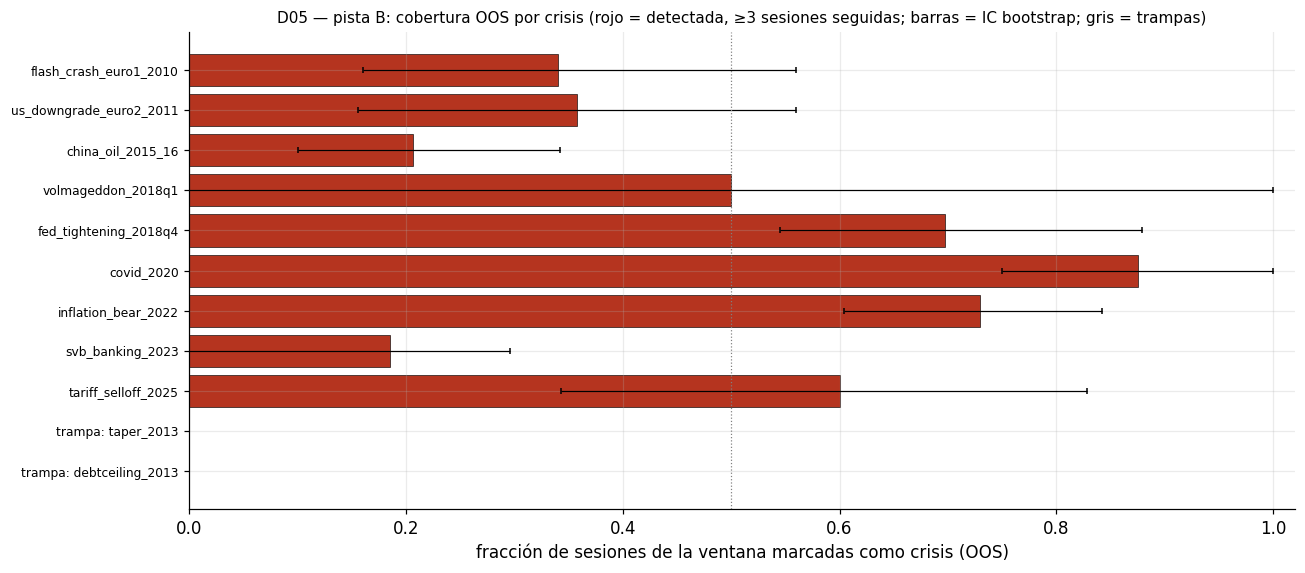

,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias
crisis,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,0.340,0.160,0.560,1.0,-38.0
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.358,0.156,0.560,1.0,-41.0
china_oil_2015_16,2015-05-21,2016-02-11,0.207,0.100,0.342,1.0,-119.0
volmageddon_2018q1,2018-01-26,2018-02-08,0.500,0.000,1.000,1.0,-4.0
fed_tightening_2018q4,2018-09-20,2018-12-24,0.697,0.545,0.879,1.0,-224.0
covid_2020,2020-02-19,2020-03-23,0.875,0.750,1.000,1.0,-217.0
inflation_bear_2022,2022-01-03,2022-10-12,0.730,0.604,0.842,1.0,-220.0
svb_banking_2023,2023-02-02,2023-03-13,0.185,0.000,0.296,1.0,-252.0
tariff_selloff_2025,2025-02-19,2025-04-08,0.600,0.343,0.829,1.0,-177.0


,activacion_trampa
taper_2013,0.0
debtceiling_2013,0.0


In [11]:
COBERTURA_D05 = {}
for t in PISTAS:
    display(Markdown(f'#### Pista {t}'))
    COBERTURA_D05[t] = figura_cobertura(t, 'D05')
    display(COBERTURA_D05[t].round(3))
    display(tabla_trampas(t, 'D05').to_frame().round(3))

<a id="s4-4"></a>
### 4.4 Métricas y puesto en el ranking de detección ADR-003

`score_deteccion` es $F_1$ entre el recall **por evento** y la precisión **diaria**; el
`nivel` filtra antes (precisión que no supera al azar, parpadeo, salida degenerada). El
puesto es dentro de cada pista (A y B nunca compiten entre sí). `puesto_legacy` es el del
`rank_medio` de cinco ejes anterior a ADR-003, solo como referencia.

In [12]:
display(resumen_ranking(['D05']).round(4))
RESUMEN_D05 = resumen_metricas('D05')
for t in PISTAS:
    r = RESUMEN_D05[f'pista {t}']
    print(f"Pista {t}: D05 queda {int(r['puesto_deteccion'])}º de {r['n_detectores_en_pista']} "
          f"({r['nivel_etiqueta']}), score {r['score_deteccion']:.3f}; detecta "
          f"{int(r['det_n_detectados'])}/{int(r['det_n_eventos'])} crisis; precisión "
          f"{r['det_precision']:.3f} (lift {r['det_lift_precision']:.2f}× sobre la tasa base "
          f"{r['det_base_rate']:.3f}); duración media de régimen {r['mean_regime_duration']:.1f} sesiones.")

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D05,5,12,elegible,0.5459,1.0,17,17,0.3755,1.9359,0.1939,0.3818,11.1718,0.7313,0.6245,0.0316,0.0683,14.6304,0.9952,4064.7255
B,D05,1,12,elegible,0.6467,1.0,9,9,0.4779,2.7671,0.1727,0.1727,7.9659,0.4990,0.5221,0.0000,0.0434,22.9322,0.9973,512.7000


Pista A: D05 queda 5º de 12 (elegible), score 0.546; detecta 17/17 crisis; precisión 0.375 (lift 1.94× sobre la tasa base 0.194); duración media de régimen 14.6 sesiones.
Pista B: D05 queda 1º de 12 (elegible), score 0.647; detecta 9/9 crisis; precisión 0.478 (lift 2.77× sobre la tasa base 0.173); duración media de régimen 22.9 sesiones.


<a id="s5"></a>
## 5. Comparación intra-familia y con familias vecinas

F4 tiene un solo detector, así que la comparación útil es doble: (i) **D05 en A frente a
D05 en B** (misma clase y mismos parámetros; cambian el periodo OOS y el conjunto de
crisis), y (ii) D05 frente a sus **parientes metodológicos** en el ranking ADR-003: los
HMM de F3 (D04 gaussiano, D08 t-Student; mismo aparato, multivariantes) y los modelos de
volatilidad de F5 (D06 GJR-GARCH-t con umbral; D11 MS-GARCH, que es D05 + dinámica
GARCH dentro de cada régimen). Las filas salen del ranking versionado.

puesto_deteccion                 detector           familia nivel_etiqueta  score_deteccion  det_event_recall  det_precision  det_lift_precision  det_marked_rate  mean_regime_duration  false_alarm_rate  \
pista id                                                                                                                                                                                                               
A     D05                 5  markov_switching_var_2s  Markov-Switching       elegible            0.546             1.000          0.375               1.936            0.382                14.630             0.625   
      D06                 7              garch_t_vol             GARCH       elegible            0.540             1.000          0.370               1.906            0.430                72.851             0.630   
      D08                 9          hmm_tstudent_4s               HMM       elegible            0.467             0.824          0.326               1.681            0.373                63.377             0.674   
      D04                10          hmm_gaussian_2s               HMM       elegible            0.455             1.000          0.294               1.518            0.561                61.448             0.706   
      D11                11           msgarch_regime             GARCH       elegible            0.443             0.765          0.312               1.610            0.306                57.686             0.688   
B     D05                 1  markov_switching_var_2s  Markov-Switching       elegible            0.647             1.000          0.478               2.767            0.173                22.932             0.522   
      D06                 2              garch_t_vol             GARCH       elegible            0.597             0.889          0.449               2.602            0.200                73.800             0.551   
      D04                 5          hmm_gaussian_2s               HMM       elegible            0.497             0.778          0.366               2.116            0.156                79.588             0.634   
      D11                 8           msgarch_regime             GARCH       elegible            0.394             0.778          0.264               1.528            0.232                13.853             0.736   
      D08                 9          hmm_tstudent_4s               HMM       elegible            0.274             0.333          0.233               1.350            0.077                55.603             0.767   

           elapsed_seconds  
pista id                    
A     D05         4064.726  
      D06          190.784  
      D08         1776.029  
      D04         6562.038  
      D11         1891.302  
B     D05          512.700  
      D06           31.162  
      D04          781.432  
      D11          233.567  
      D08          176.687

figura -> results/detectores/f4_markov_switching/F4_comparativa_vecindad_ranking.png


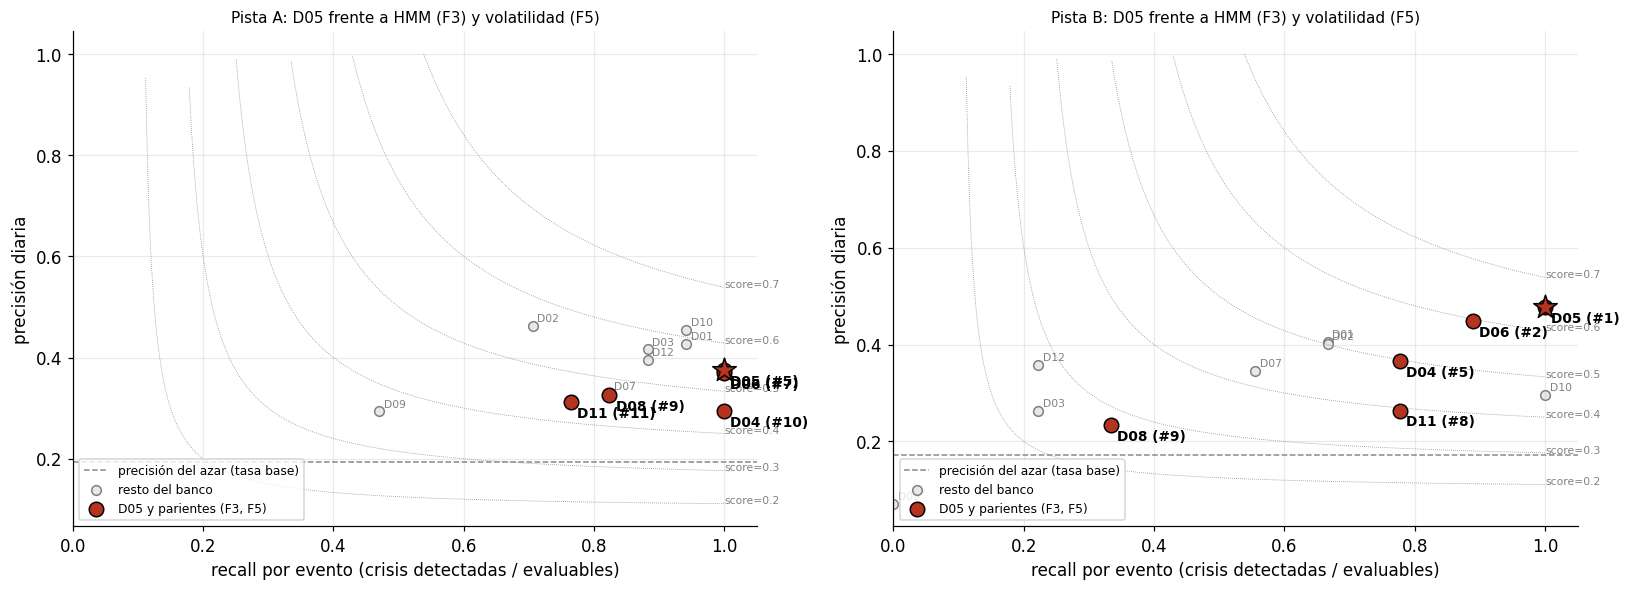

Pista A: entre D05, D06, D08, D04, D11 el mejor score es D05 (0.546); D05 0.546 frente a D11 (MS-GARCH) 0.443 y D04 (HMM gaussiano) 0.455.
Pista B: entre D05, D06, D04, D11, D08 el mejor score es D05 (0.647); D05 0.647 frente a D11 (MS-GARCH) 0.394 y D04 (HMM gaussiano) 0.497.
D05 A vs B: recall 1.000 vs 1.000; precisión 0.375 vs 0.478; tasa de marcado 0.382 vs 0.173; duración media 14.6 vs 22.9.


In [13]:
VECINOS = ['D04', 'D05', 'D06', 'D08', 'D11']
cols = ['pista', 'puesto_deteccion', 'id', 'detector', 'familia', 'nivel_etiqueta', 'score_deteccion',
        'det_event_recall', 'det_precision', 'det_lift_precision', 'det_marked_rate',
        'mean_regime_duration', 'false_alarm_rate', 'elapsed_seconds']
VECINDAD = RANKING[RANKING.id.isin(VECINOS)][[c for c in cols if c in RANKING]].sort_values(
    ['pista', 'puesto_deteccion'])
display(VECINDAD.set_index(['pista', 'id']).round(3))

fig, axes = plt.subplots(1, len(PISTAS), figsize=(7.5 * len(PISTAS), 5.5), squeeze=False)
for ax, t in zip(axes[0], PISTAS):
    todos = RANKING[RANKING.pista == t]
    inf.dibujar_plano_ranking(ax, todos, VECINOS, beta=BETA, etiqueta='D05 y parientes (F3, F5)',
                              titulo=f'Pista {t}: D05 frente a HMM (F3) y volatilidad (F5)')
    d05 = todos[todos.id == 'D05']
    ax.scatter(d05.det_event_recall, d05.det_precision, marker='*', s=260, color=viz.C_CRISIS,
               edgecolor='black', zorder=5)
fig.tight_layout()
guardar(fig, 'F4_comparativa_vecindad_ranking')
plt.show()

for t in PISTAS:
    part = VECINDAD[VECINDAD.pista == t].set_index('id')
    mejor = part['score_deteccion'].idxmax()
    print(f"Pista {t}: entre {', '.join(part.index)} el mejor score es {mejor} "
          f"({part.loc[mejor, 'score_deteccion']:.3f}); D05 {part.loc['D05', 'score_deteccion']:.3f} "
          f"frente a D11 (MS-GARCH) {part.loc['D11', 'score_deteccion']:.3f} y "
          f"D04 (HMM gaussiano) {part.loc['D04', 'score_deteccion']:.3f}.")
dA, dB = (METRICAS.loc[(t, 'D05')] for t in PISTAS)
print(f"D05 A vs B: recall {dA.det_event_recall:.3f} vs {dB.det_event_recall:.3f}; precisión "
      f"{dA.det_precision:.3f} vs {dB.det_precision:.3f}; tasa de marcado {dA.det_marked_rate:.3f} vs "
      f"{dB.det_marked_rate:.3f}; duración media {dA.mean_regime_duration:.1f} vs {dB.mean_regime_duration:.1f}.")

<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2

**Hallazgos v1** (`docs/detectores/D05_markov_switching_var.md`, notebook v1
`05_markov_switching_var.ipynb` del tag git `capa1-final`; la hipótesis del CHECKPOINT 2 y su
veredicto, en §6.1):

1. **Orientación correcta sin parches.** Con `market_returns` explícito, el régimen de
   crisis resultó el de mayor varianza y media negativa; D05 no sufrió la inversión de
   etiquetas que destapó D06 (sus regímenes separan también en media).
2. **Causalidad verificada.** El filtro forward propio reproducía las filtradas de
   `statsmodels` a precisión de máquina; las suavizadas se usaron solo in-sample y
   marcadas como no causales.
3. **Buena cobertura de las grandes crisis evaluables OOS** (GFC, deuda europea, COVID,
   2022) y **punto ciego en el *taper* de 2013** (shock de tipos sin volatilidad de
   *equity*), mientras que el sell-off de Q4-2018 sí lo disparaba. *(Lectura v1. En v2 el
   taper es una trampa del catálogo: no activarse en él es el comportamiento correcto, no un
   punto ciego; ver §6.1.)*
4. **Persistencia muy superior a un clustering sin memoria** y `false_alarm_rate` alto:
   marcaba como crisis episodios de volatilidad real fuera de las ventanas
   etiquetadas de v1 (LTCM, 2002, 2010, 2015-16, SVB…).
5. **AIC y BIC preferían un régimen más** (un tercer régimen de varianza muy alta para
   los extremos); se mantuvo el $K$ del baseline por interpretabilidad.
6. **Coste**: refit espaciado (`step` del registro) por el EM con ventana *expanding*.

**Qué se mantiene en v2.** La clase y su lógica (misma implementación de la Capa 1,
hoy en `regimenes.detectores.f4_switching`), el $K$, la frecuencia de refit, el filtrado causal con
burn-in y el etiquetado económico por fold.

**Qué cambia en v2.** (i) Dos pistas: A (histórico largo, muchas crisis de catálogo) y B
(multi-activo, desde que existen VIX/MOVE/crédito), con **índice OOS común** a los doce
detectores; (ii) el retorno se deriva de la espina cruda del S&P 500 dentro del
benchmark; (iii) las ventanas de crisis salen del catálogo congelado
(`configs/benchmark_spec.yaml`) y el sell-off de Q4-2018 pasa a ser **crisis** (positivo),
no trampa; (iv) el criterio principal es el **ranking de detección ADR-003** (recall por
evento + precisión con restricción de azar), no la cobertura media; (v) el walk-forward
propaga contexto de estado entre bloques (ADR-003), inocuo para D05 porque ya antepone
su burn-in. La tabla compara v1 con v2 en las métricas homologables; las ventanas no son
idénticas (v1 usaba ventanas propias y OOS desde 1993), así que la comparación es
cualitativa.

In [14]:
V1_DIR = rutas.DOCS / 'historia' / 'capa1' / 'resultados'
# Ventanas v1 (4 crisis + 2 trampas, ventana_eval 1993–2026) → ventana v2 más parecida.
# En v2 el sell-off de Q4-2018 es CRISIS de catálogo (positivo), no trampa.
MAPA_V1_V2 = {
    'cov_GFC_2008': 'cov_gfc_2007_09',
    'cov_EuroDebt_2011': 'cov_us_downgrade_euro2_2011',
    'cov_COVID_2020': 'cov_covid_2020',
    'cov_Inflation_2022': 'cov_inflation_bear_2022',
    'fa_Selloff_Q4_2018': 'cov_fed_tightening_2018q4',
    'fa_TaperTantrum_2013': 'fa_taper_2013',
}
COMUNES = ['ventana_eval', 'false_alarm_rate', 'switching_rate', 'mean_regime_duration',
           'label_stability', 'aic', 'bic']


def tabla_v1_v2(d, archivo_v1):
    ruta = V1_DIR / archivo_v1
    if not ruta.exists():
        print(f'No se encuentra {rel(ruta)}; se omite la comparación v1.')
        return None
    v1 = pd.read_csv(ruta).iloc[0]
    filas = []
    for c in COMUNES:
        filas.append({'métrica v1': c, 'Capa 1 (v1)': v1.get(c), 'métrica v2': c,
                      **{f'v2 pista {t}': METRICAS.loc[(t, d)].get(c) for t in PISTAS}})
    for c1, c2 in MAPA_V1_V2.items():
        filas.append({'métrica v1': c1, 'Capa 1 (v1)': v1.get(c1), 'métrica v2': c2,
                      **{f'v2 pista {t}': METRICAS.loc[(t, d)].get(c2) for t in PISTAS}})
    return pd.DataFrame(filas).set_index('métrica v1')

In [15]:
V1_D05 = tabla_v1_v2('D05', 'metrics_05_markov_switching_var.csv')
if V1_D05 is not None:
    display(V1_D05)
    v1 = V1_D05['Capa 1 (v1)']
    print(f"v1: taper 2013 = {float(v1['fa_TaperTantrum_2013']):.1%} (trampa) y Q4-2018 = "
          f"{float(v1['fa_Selloff_Q4_2018']):.1%} (trampa en v1, crisis en v2).")
    pct = lambda v: 'fuera del OOS' if pd.isna(v) else f'{float(v):.1%}'
    for t in PISTAS:
        m = METRICAS.loc[(t, 'D05')]
        print(f"v2 pista {t}: taper 2013 = {pct(m['fa_taper_2013'])}; Q4-2018 (crisis) = "
              f"{pct(m['cov_fed_tightening_2018q4'])}; false_alarm_rate {float(v1['false_alarm_rate']):.3f} (v1) → "
              f"{m['false_alarm_rate']:.3f}; duración media {float(v1['mean_regime_duration']):.1f} (v1) → "
              f"{m['mean_regime_duration']:.1f} sesiones.")

,Capa 1 (v1),métrica v2,v2 pista A,v2 pista B
métrica v1,,,,
ventana_eval,1993-03-23→2026-06-12 (n=8278),ventana_eval,1970-05-12→2026-05-29 (n=14133),2010-04-12→2026-05-29 (n=4059)
false_alarm_rate,0.774353,false_alarm_rate,0.624537,0.522111
switching_rate,0.05569,switching_rate,0.06828,0.04336
mean_regime_duration,17.917749,mean_regime_duration,14.630435,22.932203
label_stability,0.997577,label_stability,0.995217,0.997272
aic,27980.334228,aic,41464.411449,13583.979223
bic,28023.770127,bic,41510.549129,13622.85617
cov_GFC_2008,0.993151,cov_gfc_2007_09,0.879213,NaN
cov_EuroDebt_2011,0.741176,cov_us_downgrade_euro2_2011,0.431193,0.357798


v1: taper 2013 = 3.8% (trampa) y Q4-2018 = 81.0% (trampa en v1, crisis en v2).
v2 pista A: taper 2013 = 6.3%; Q4-2018 (crisis) = 75.8%; false_alarm_rate 0.774 (v1) → 0.625; duración media 17.9 (v1) → 14.6 sesiones.
v2 pista B: taper 2013 = 0.0%; Q4-2018 (crisis) = 69.7%; false_alarm_rate 0.774 (v1) → 0.522; duración media 17.9 (v1) → 22.9 sesiones.


<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

**Hipótesis v1** (cabecera y §12 del notebook v1 `05_markov_switching_var.ipynb`, tag git
`capa1-final`; ficha `docs/detectores/D05_markov_switching_var.md`, apartado «Hipótesis del
CHECKPOINT 2 para D5 — veredicto»): *«Baseline econométrico interpretable; capta calma/estrés;
punto ciego en crisis rápidas; univariante → no ve correlación cross-asset; gaussiano insuficiente
para colas.»*

**Veredicto v1: se cumple**, punto por punto:

1. **Interpretable**: medias, varianzas y persistencia por régimen legibles; crisis = alta varianza.
2. **Capta calma/estrés** y las crisis evaluables OOS de v1, incluida la GFC.
3. **Punto ciego en crisis rápidas** confirmado: el *taper* de 2013 no lo disparaba. *(Esta
   prueba v1 no era adecuada: el taper no es una crisis rápida del catálogo, sino una trampa
   donde no activarse es correcto. v2 juzga la hipótesis con las crisis rápidas.)*
4. **Univariante**: solo el S&P 500, sin crédito, curva ni correlación cross-asset; es su límite
   estructural frente a un detector multivariante.
5. **Gaussiano por régimen**: la mezcla de gaussianas mitiga, pero no elimina, las colas (curtosis
   muy alta), coherente con que AIC/BIC pidieran un tercer régimen de varianza muy alta.

**Qué dice v2.** La celda siguiente recalcula cada punto con la caché del benchmark y el ranking
ADR-003:

1. La **verosimilitud y los criterios de información** del ajuste final (el detalle por régimen
   está en §4.2 a–b y la comparación K frente a K+1 en §4.2 e).
2. Las **crisis detectadas por evento** y el lift de precisión.
3. **Crisis rápidas**: detección por evento (racha mínima ADR-003) y cobertura de los episodios
   cortos del catálogo (Black Monday 1987, flash crash 2010, Volmageddon 2018). Es aquí donde se
   contrasta «punto ciego en crisis rápidas». Aparte, la activación en la **trampa** del *taper*
   (menos es mejor): no es una prueba de la hipótesis, sino de falsas alarmas.
4. El score frente a los **HMM multivariantes** (D04, D08).
5. La **curtosis en exceso** del retorno OOS dentro de cada régimen de D05: si es > 0, las colas
   siguen siendo más pesadas que la gaussiana dentro del régimen.

In [16]:
# Hipótesis del CHECKPOINT 2 (v1) frente a v2. Cifras v1: CSV archivado de la Capa 1;
# cifras v2: caché verificada del benchmark (METRICAS), ranking ADR-003 (RANKING) y paneles OOS.
CP2_V1 = pd.read_csv(V1_DIR / 'metrics_05_markov_switching_var.csv').iloc[0]
cp2 = lambda t, col: METRICAS.loc[(t, 'D05')].get(col, np.nan)
pct = lambda x: 'fuera del OOS' if pd.isna(x) else f'{100 * float(x):.0f} %'
RAPIDAS = {'black_monday_1987': 'Black Monday 1987', 'flash_crash_euro1_2010': 'flash crash 2010',
           'volmageddon_2018q1': 'Volmageddon 2018'}   # episodios cortos del catálogo v2
lineas = [
    f"- **v1**: {int(CP2_V1['n_states'])} regímenes; logL {float(CP2_V1['log_likelihood']):,.0f}, BIC "
    f"{float(CP2_V1['bic']):,.0f}; GFC {pct(CP2_V1['cov_GFC_2008'])}, 2011 {pct(CP2_V1['cov_EuroDebt_2011'])}, "
    f"COVID {pct(CP2_V1['cov_COVID_2020'])}, 2022 {pct(CP2_V1['cov_Inflation_2022'])}; taper 2013 "
    f"{pct(CP2_V1['fa_TaperTantrum_2013'])}."]
for t in PISTAS:
    r = RANKING[RANKING.pista == t].set_index('id')
    multiv = [v for v in ('D04', 'D08') if v in r.index]
    ev_rap = {k: cp2(t, f'det_ev_{k}') for k in RAPIDAS if pd.notna(cp2(t, f'cov_{k}'))}
    rapidas = [f"{RAPIDAS[k]} {pct(cp2(t, f'cov_{k}'))} ({'detectada' if v == 1 else 'no detectada'})"
               for k, v in ev_rap.items()]
    n_det = sum(float(v) == 1 for v in ev_rap.values())
    if not ev_rap:
        txt_rap = 'sin crisis rápidas evaluables'
    elif n_det == len(ev_rap):
        txt_rap = 'el «punto ciego en crisis rápidas» NO se sostiene: las detecta todas'
    elif n_det == 0:
        txt_rap = 'el «punto ciego en crisis rápidas» se sostiene: no detecta ninguna'
    else:
        txt_rap = f'el «punto ciego en crisis rápidas» se sostiene solo en parte: detecta {n_det} de {len(ev_rap)}'
    tap = cp2(t, 'fa_taper_2013')
    texto = (
        f"- **v2 pista {t}**: (1) {int(cp2(t, 'n_states'))} regímenes, logL {cp2(t, 'log_likelihood'):,.0f}, "
        f"BIC {cp2(t, 'bic'):,.0f}; (2) crisis detectadas por evento {int(cp2(t, 'det_n_detectados'))} de "
        f"{int(cp2(t, 'det_n_eventos'))}, lift de precisión {cp2(t, 'det_lift_precision'):.2f}×; "
        f"(3) crisis rápidas: {', '.join(rapidas) or '—'} → {txt_rap}; trampa del taper 2013 {pct(tap)} → "
        + ('no evaluable' if pd.isna(tap) else ('sin falsa alarma sostenida (correcto en v2)' if tap < 0.10
                                                else 'falsa alarma parcial en la trampa'))
        + f"; (4) score D05 {r.loc['D05', 'score_deteccion']:.3f} ({int(r.loc['D05', 'puesto_deteccion'])}º) frente a "
        + ', '.join(f"{v} {r.loc[v, 'score_deteccion']:.3f}" for v in multiv))
    x = globals().get('X_PISTA', {}).get((t, 'D05'))
    if x is not None:
        ret = x.iloc[:, 0].reindex(PANELES[(t, 'D05')].index)
        crisis = es_crisis(t, 'D05')
        kurt = {'calma': ret[~crisis].kurt(), 'crisis': ret[crisis].kurt()}
        texto += ('; (5) curtosis en exceso del retorno OOS por régimen: '
                  + ', '.join(f'{k} {v:.1f}' for k, v in kurt.items()) + ' → '
                  + ('las colas siguen sin ser gaussianas dentro del régimen' if max(kurt.values()) > 0
                     else 'sin exceso de colas dentro del régimen'))
    lineas.append(texto + '.')
display(Markdown('\n'.join(lineas)))

- **v1**: 2 regímenes; logL -13,984, BIC 28,024; GFC 99 %, 2011 74 %, COVID 96 %, 2022 74 %; taper 2013 4 %.
- **v2 pista A**: (1) 2 regímenes, logL -20,726, BIC 41,511; (2) crisis detectadas por evento 17 de 17, lift de precisión 1.94×; (3) crisis rápidas: Black Monday 1987 100 % (detectada), flash crash 2010 92 % (detectada), Volmageddon 2018 50 % (detectada) → el «punto ciego en crisis rápidas» NO se sostiene: las detecta todas; trampa del taper 2013 6 % → sin falsa alarma sostenida (correcto en v2); (4) score D05 0.546 (5º) frente a D04 0.455, D08 0.467; (5) curtosis en exceso del retorno OOS por régimen: calma 0.4, crisis 12.6 → las colas siguen sin ser gaussianas dentro del régimen.
- **v2 pista B**: (1) 2 regímenes, logL -6,786, BIC 13,623; (2) crisis detectadas por evento 9 de 9, lift de precisión 2.77×; (3) crisis rápidas: flash crash 2010 34 % (detectada), Volmageddon 2018 50 % (detectada) → el «punto ciego en crisis rápidas» NO se sostiene: las detecta todas; trampa del taper 2013 0 % → sin falsa alarma sostenida (correcto en v2); (4) score D05 0.647 (1º) frente a D04 0.497, D08 0.274; (5) curtosis en exceso del retorno OOS por régimen: calma 1.2, crisis 3.6 → las colas siguen sin ser gaussianas dentro del régimen.

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas.**
- **Interpretabilidad econométrica**: cada régimen tiene media, volatilidad, persistencia
  y duración esperada legibles (§4.2a–b); la probabilidad de crisis es una probabilidad
  filtrada genuina, no una sigmoide de un umbral.
- **Causalidad limpia**: filtrado forward con parámetros congelados; la comparación
  filtrada/suavizada (§4.2c) cuantifica el sesgo que evita.
- **Persistencia endógena**: la diagonal de $P$ controla el parpadeo sin reglas *ad hoc*
  de histéresis.
- **Una sola serie**: funciona con el histórico más largo disponible y no depende de
  series que empiezan tarde.

**Limitaciones.**
- **Univariante**: no ve crédito, curva ni correlaciones; los shocks de tipos o de crédito
  sin volatilidad de *equity* le son invisibles por construcción. (En el catálogo v2 el
  *taper* de 2013 es una trampa, así que ahí esa ceguera no penaliza: evita la falsa alarma.)
- **Gaussiano dentro del régimen**: dos gaussianas no bastan para las colas; el criterio
  de información pide más regímenes (§4.2e, §6).
- **Varianza constante dentro del régimen**: la entrada en crisis es gradual (el filtro
  necesita varias observaciones de cola) y su señal es más ruidosa que la del GJR-GARCH con
  histéresis de D06 (duración media de régimen menor en ambas pistas; ver §5).
- **Coste**: el EM sobre ventana *expanding* obliga a reajustar cada `step` sesiones.
- **Falsas alarmas frente al catálogo**: cualquier episodio de alta volatilidad fuera de
  las ventanas etiquetadas cuenta como falsa alarma.

**Conclusión.** La celda siguiente resume, con las métricas vigentes, el papel de D05
en cada pista: su puesto en el ranking ADR-003, si supera a su extensión MS-GARCH (D11) y
al HMM gaussiano (D04), y si detecta todas las crisis evaluadas.

In [17]:
lineas = []
for t in PISTAS:
    r = RANKING[RANKING.pista == t].set_index('id')
    d05 = r.loc['D05']
    n = len(r)
    supera = [v for v in ('D04', 'D06', 'D08', 'D11') if d05.score_deteccion > r.loc[v, 'score_deteccion']]
    no_supera = [v for v in ('D04', 'D06', 'D08', 'D11') if v not in supera]
    lineas.append(
        f"- **Pista {t}**: D05 {int(d05.puesto_deteccion)}º de {n} (score {d05.score_deteccion:.3f}, "
        f"`{d05.nivel_etiqueta}`). Recall por evento {d05.det_event_recall:.3f}"
        f"{' (todas las crisis evaluadas)' if d05.det_event_recall == 1 else ''}; "
        f"lift de precisión {d05.det_lift_precision:.2f}×. "
        f"Supera en score a: {', '.join(supera) or 'ninguno'}; no supera a: {', '.join(no_supera) or 'ninguno'}.")
display(Markdown('\n'.join(lineas)))

- **Pista A**: D05 5º de 12 (score 0.546, `elegible`). Recall por evento 1.000 (todas las crisis evaluadas); lift de precisión 1.94×. Supera en score a: D04, D06, D08, D11; no supera a: ninguno.
- **Pista B**: D05 1º de 12 (score 0.647, `elegible`). Recall por evento 1.000 (todas las crisis evaluadas); lift de precisión 2.77×. Supera en score a: D04, D06, D08, D11; no supera a: ninguno.

In [18]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f4_markov_switching:
  - D05_A_cobertura_crisis.png
  - D05_A_estados_oos.png
  - D05_A_filtrada_vs_suavizada.png
  - D05_B_cobertura_crisis.png
  - D05_B_estados_oos.png
  - D05_B_filtrada_vs_suavizada.png
  - D05_retorno_oos_por_regimen.png
  - D05_transicion.png
  - F4_comparativa_vecindad_ranking.png
